In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\udayb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv("3) Sentiment dataset.csv")
print("First five rows:")
print(df.head())

First five rows:
   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   
3             3           3   
4             4           4   

                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     
3   Excited about the upcoming weekend getaway!  ...   Positive     
4   Trying out a new recipe for dinner tonight.  ...   Neutral      

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123          Twitter     
1  2023-01-15 08:45:00   CommuterX        Twitter     
2  2023-01-15 15:45:00   FitnessFan      Instagram    
3  2023-01-15 18:20:00   AdventureX       Facebook    
4  2023-01-15 19:55:00   ChefCook        Instagram    

                                     Hashtags  Ret

In [4]:
print("Dataset Shape:")
print(df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape:
(732, 15)

Column Names:
['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']


In [5]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64


In [7]:
df = df[["Text", "Sentiment"]]
print(df.head())

                                                Text    Sentiment
0   Enjoying a beautiful day at the park!        ...   Positive  
1   Traffic was terrible this morning.           ...   Negative  
2   Just finished an amazing workout! 💪          ...   Positive  
3   Excited about the upcoming weekend getaway!  ...   Positive  
4   Trying out a new recipe for dinner tonight.  ...   Neutral   


In [8]:
df = df.dropna()
print("Dataset shape after removing missing values:")
print(df.shape)

Dataset shape after removing missing values:
(732, 2)


In [9]:
print("Sentiment Classes:")
print(df["Sentiment"].unique())
print("\nSentiment Distribution:")
print(df["Sentiment"].value_counts())

Sentiment Classes:
[' Positive  ' ' Negative  ' ' Neutral   ' ' Anger        '
 ' Fear         ' ' Sadness      ' ' Disgust      ' ' Happiness    '
 ' Joy          ' ' Love         ' ' Amusement    ' ' Enjoyment    '
 ' Admiration   ' ' Affection    ' ' Awe          ' ' Disappointed '
 ' Surprise     ' ' Acceptance   ' ' Adoration    ' ' Anticipation '
 ' Bitter       ' ' Calmness     ' ' Confusion    ' ' Excitement   '
 ' Kind         ' ' Pride        ' ' Shame        ' ' Confusion '
 ' Excitement ' ' Shame ' ' Elation       ' ' Euphoria      '
 ' Contentment   ' ' Serenity      ' ' Gratitude     ' ' Hope          '
 ' Empowerment   ' ' Compassion    ' ' Tenderness    ' ' Arousal       '
 ' Enthusiasm    ' ' Fulfillment  ' ' Reverence     ' ' Compassion'
 ' Fulfillment   ' ' Reverence ' ' Elation   ' ' Despair         '
 ' Grief           ' ' Loneliness      ' ' Jealousy        '
 ' Resentment      ' ' Frustration     ' ' Boredom         '
 ' Anxiety         ' ' Intimidation    ' ' He

In [10]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
def preprocess_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    words = text.split()
    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]
    return " ".join(words)

In [11]:
df["Clean_Text"] = df["Text"].apply(preprocess_text)
print(df[["Text", "Clean_Text"]].head(10))

                                                Text  \
0   Enjoying a beautiful day at the park!        ...   
1   Traffic was terrible this morning.           ...   
2   Just finished an amazing workout! 💪          ...   
3   Excited about the upcoming weekend getaway!  ...   
4   Trying out a new recipe for dinner tonight.  ...   
5   Feeling grateful for the little things in lif...   
6   Rainy days call for cozy blankets and hot coc...   
7   The new movie release is a must-watch!       ...   
8   Political discussions heating up on the timel...   
9   Missing summer vibes and beach days.         ...   

                              Clean_Text  
0                  enjoy beauti day park  
1                   traffic terribl morn  
2                    finish amaz workout  
3            excit upcom weekend getaway  
4           tri new recip dinner tonight  
5            feel grate littl thing life  
6  raini day call cozi blanket hot cocoa  
7              new movi releas mustwatc

In [12]:
X = df["Clean_Text"]
y = df["Sentiment"]
print("Input Text:")
print(X.head())
print("\nTarget Sentiment:")
print(y.head())

Input Text:
0           enjoy beauti day park
1            traffic terribl morn
2             finish amaz workout
3     excit upcom weekend getaway
4    tri new recip dinner tonight
Name: Clean_Text, dtype: object

Target Sentiment:
0     Positive  
1     Negative  
2     Positive  
3     Positive  
4     Neutral   
Name: Sentiment, dtype: object


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 585
Testing samples: 147


In [14]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Training TF-IDF Shape:")
print(X_train_tfidf.shape)
print("\nTesting TF-IDF Shape:")
print(X_test_tfidf.shape)

Training TF-IDF Shape:
(585, 1757)

Testing TF-IDF Shape:
(147, 1757)


In [15]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf,y_train)

LogisticRegression(max_iter=1000)

In [16]:
y_pred = model.predict(X_test_tfidf)
print("Predicted Sentiments:")
print(y_pred[:10])

Predicted Sentiments:
[' Positive  ' ' Positive  ' ' Joy ' ' Excitement ' ' Joy ' ' Positive  '
 ' Excitement ' ' Positive  ' ' Joy ' ' Positive  ']


In [17]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.09523809523809523


In [18]:
precision = precision_score(y_test,y_pred,average="weighted")
recall = recall_score(y_test,y_pred,average="weighted")
f1 = f1_score(y_test,y_pred,average="weighted")
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.025221031173412123
Recall: 0.09523809523809523
F1 Score: 0.033936556701533664


C:\Users\udayb\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\udayb\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
print("Classification Report:")
print(classification_report(y_test,y_pred))

Classification Report:


C:\Users\udayb\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\udayb\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                        precision    recall  f1-score   support

         Acceptance          0.00      0.00      0.00         2
      Acceptance             0.00      0.00      0.00         0
           Admiration        0.00      0.00      0.00         1
        Admiration           0.00      0.00      0.00         1
         Affection           0.00      0.00      0.00         1
      Ambivalence            0.00      0.00      0.00         1
         Anger               0.00      0.00      0.00         1
        Anticipation         0.00      0.00      0.00         1
        Arousal              0.00      0.00      0.00         3
                  Awe        0.00      0.00      0.00         1
         Awe                 0.00      0.00      0.00         1
                  Bad        0.00      0.00      0.00         1
             Betrayal        0.00      0.00      0.00         2
        Betrayal             0.00      0.00      0.00         1
         Bitter              0.00      

C:\Users\udayb\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\udayb\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\udayb\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\udayb\anaconda3\Lib\site-packages\sklea

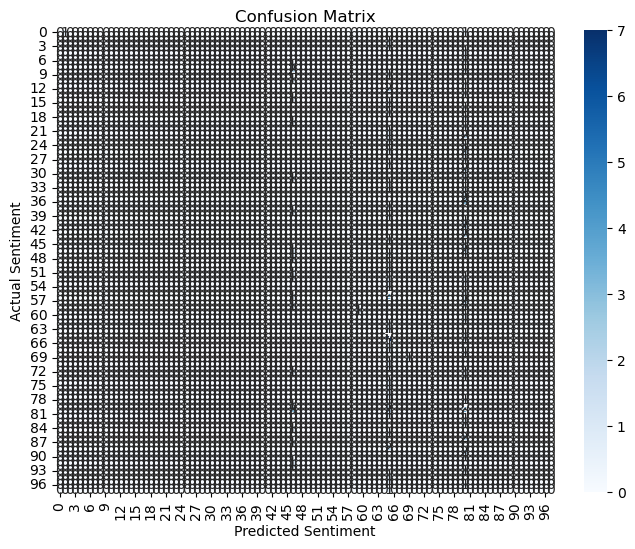

In [21]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Confusion Matrix")
plt.show()